# Module Seven Activity

For the module seven activity, you will identify relevant data and write Python code to generate visualizations and interpret insights from the provided data set. Professionals in data-driven fields must not only interpret data but also gather, analyze, and present it in meaningful and actionable ways. This activity allows you to practice these essential skills by working through the complete exploratory data analysis (EDA) process.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Note:</i></b> there are two parts to this assignment. Part One is the coding activity. Part Two is the written report.</span>
</div>

Once your code is complete, you will download this notebook as an HTML file by clicking **File**, then **Download As**, then **HTML (.html)** from the Jupyter menu bar. Validate that your code, output, and all visualizations (rendered as images using the display() function) are visible in the html file before submission.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Missing Blocks:</i></b> Ensure that you have clicked <b><mark>Run</mark></b> for all blocks before downloading as an HTML file or the block may be missing from your submission. <b>Images</b> must be called using the <b><i>display()</i></b> function, for example: <b><mark>display(Image(filename="output/{image_name}.png"))</mark></b></span>
</div>

Specifically, you must address the items from the rubric criteria.

### Part One: Python Code
In this part, you will write Python code to analyze the data and generate visualizations that explore trends.

#### Create multiple, distinct visualizations that explore different aspects of the data using Python Libraries. 
Include the following: 
- Code comments explaining each step of your analysis

### Part Two: Report
In this part, you will write a reflection to explain the insights gained from your analysis and visualizations. <i>This part is to be completed in a word document, using the output here to answer the topics.</i>
- Explain the trends, differences, or outliers you observed in the data. 
- Describe any disparities or patterns that may be relevant to the nonprofit’s goals. 
- Write a summary of what the data suggests about transit usage across neighborhoods. 
- Explain how the visualizations support your conclusions. 
- Discuss how your findings could inform the nonprofit’s decision-making or strategy. 
- Describe the importance of data-driven insights in addressing real-world challenges.

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> This Python template program has been broken down into segments as a guide for what steps you should do at a minimum to complete this activity. Look for the <b># To Do:</b> comments. These are placeholders for you to provide Python code segments. Fill out all <b># To Do:</b> code segments to complete this program.</span><br/><br/>
    <span style="color:black"><b><i>Once Complete:</i></b> Execute a "Kernel restart and run all" to verify that all your code works as a single unit by clicking <b>Kernel</b>, then <b>Restart & Run All</b> before downloading as html.</span>
</div>

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Hint:</i></b> If you need to install additional packages, see one of the earlier modules on how to configure and call a requirements.txt file.</span>
</div>

## Import the Required Packages

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.image as mpimg

from IPython.display import Image, display # for image rendering in html output

# Part One: Python Code

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>Reminder:</i></b> Ensure that you add code comments explaining each step of your analysis.</span>
</div>

## Define the file path for the dataset

In [3]:
data_path = "data/Feb_2025_Complete_Monthly_Ridership.csv"

## Loading the dataset

In [4]:
# Loads the dataset
data = pd.read_csv(data_path)

## Create an output folder if it doesn't already exist

In [5]:
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

## Display Dataset Information

In [6]:
# Displays the first 5 rows to confirm that the dataset loaded correctly
display(data.head())

,NTD ID,Legacy NTD ID,Agency,Mode,TOS,3 Mode,Mode/Type of Service Status,Reporter Type,Organization Type,HQ City,...,Last Closed Report Year,Last Closed FY End Month,Last Closed FY End Year,Passenger Miles FY,Unlinked Passenger Trips FY,Avg Trip Length FY,Fares FY,Operating Expenses FY,Avg Cost Per Trip FY,Avg Fares Per Trip FY
0,1,0001,King County,DR,PT,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"6,470,644","888,663",7.0,"$816,892.00","$72,095,003.00",$81.13,$0.92
1,1,0001,King County,DR,TX,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"1,509,526","121,496",12.0,"$105,605.00","$5,658,724.00",$46.58,$0.87
2,1,0001,King County,FB,DO,Ferry,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"1,479,694","399,687",4.0,"$1,493,280.00","$8,625,721.00",$21.58,$3.74
3,1,0001,King County,LR,DO,Rail,Inactive,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2011.0,12.0,2011.0,"471,587","520,933",1.0,"$288,470.00","$2,281,393.00",$4.38,$0.55
4,1,0001,King County,MB,DO,Bus,Active,Full Reporter,"City, County or Local Government Unit or Depar...",SEATTLE,...,2023.0,12.0,2023.0,"244,710,079","63,485,248",4.0,"$60,386,305.00","$710,359,423.00",$11.19,$0.95


In [7]:
print("Column Names:")

# Prints all column names in the dataset
print(data.columns.tolist())

Column Names:
['NTD ID', 'Legacy NTD ID', 'Agency', 'Mode', 'TOS', '3 Mode', 'Mode/Type of Service Status', 'Reporter Type', 'Organization Type', 'HQ City', 'HQ State', 'UACE CD', 'UZA Name', 'UZA SQ Miles', 'UZA Population', 'Service Area Population', 'Service Area SQ Miles', 'Last Closed Report Year', 'Last Closed FY End Month', 'Last Closed FY End Year', 'Passenger Miles FY', 'Unlinked Passenger Trips FY', 'Avg Trip Length FY', 'Fares FY', 'Operating Expenses FY', 'Avg Cost Per Trip FY', 'Avg Fares Per Trip FY']


In [8]:
# Defines the three agencies to include
neighborhoods = [
    "King County",
    "City of Longview",
    "Spokane Transit Authority"
]

# Filters the dataset and create an explicit copy
filtered_data = data[
    data["Agency"].isin(neighborhoods)
].copy()

In [9]:
# Convert numeric columns stored as text into proper numeric values
for column in filtered_data.columns:
    if filtered_data[column].dtype == "object":
        # Remove commas and extra spaces
        cleaned_values = (
            filtered_data[column]
            .astype("string")
            .str.replace(",", "", regex=False)
            .str.strip()
        )

        # Attempt to convert the cleaned values to numbers
        numeric_values = pd.to_numeric(
            cleaned_values,
            errors="coerce"
        )

        # Convert only columns whose nonblank values are numeric
        nonblank_values = cleaned_values.notna() & cleaned_values.ne("")

        if (
            nonblank_values.any()
            and numeric_values[nonblank_values].notna().all()
        ):
            filtered_data[column] = numeric_values

## Generate, Save, and Output Visualizations

<div class="alert alert-block alert-info">
    <span style="color:black"><b><i>Example Visualizations:</i></b> The three visualization placeholders below are example visualization placeholders for the data using a provided template. These are simple example frameworks that you may use, but you may, and are encouraged to develop your own visualizations that you will then explain how the selected visualizations support your conclusions in the part two report.</span>
</div>

<div class="alert alert-block alert-success">
    <span style="color:black">In accordance with the scenario, three neighborhoods for evaluation are: King County, City of Longview, and Spokane Transit Authority which have been listed in the <mark>neighborhoods</mark> variable above.</span>
</div>

### Visualization 1: Line chart of ridership trends over years
This is an example visualization you can generate. You may implement a chart and assessment of your choosing in lieu of this placeholder.

#### At a minimum include the following actions:
- Add title and axis labels
- Save the plot to a png file in the 'output' folder
- Use the display() function to render the generated png image in the html output
- Comments explaining each step of your analysis

Ridership trend data:


,Last Closed FY End Year,Agency,Unlinked Passenger Trips FY
1,2017,City of Longview,18
2,2023,City of Longview,274804
0,2011,King County,520933
3,2023,King County,78886848
4,2023,Spokane Transit Authority,9403739


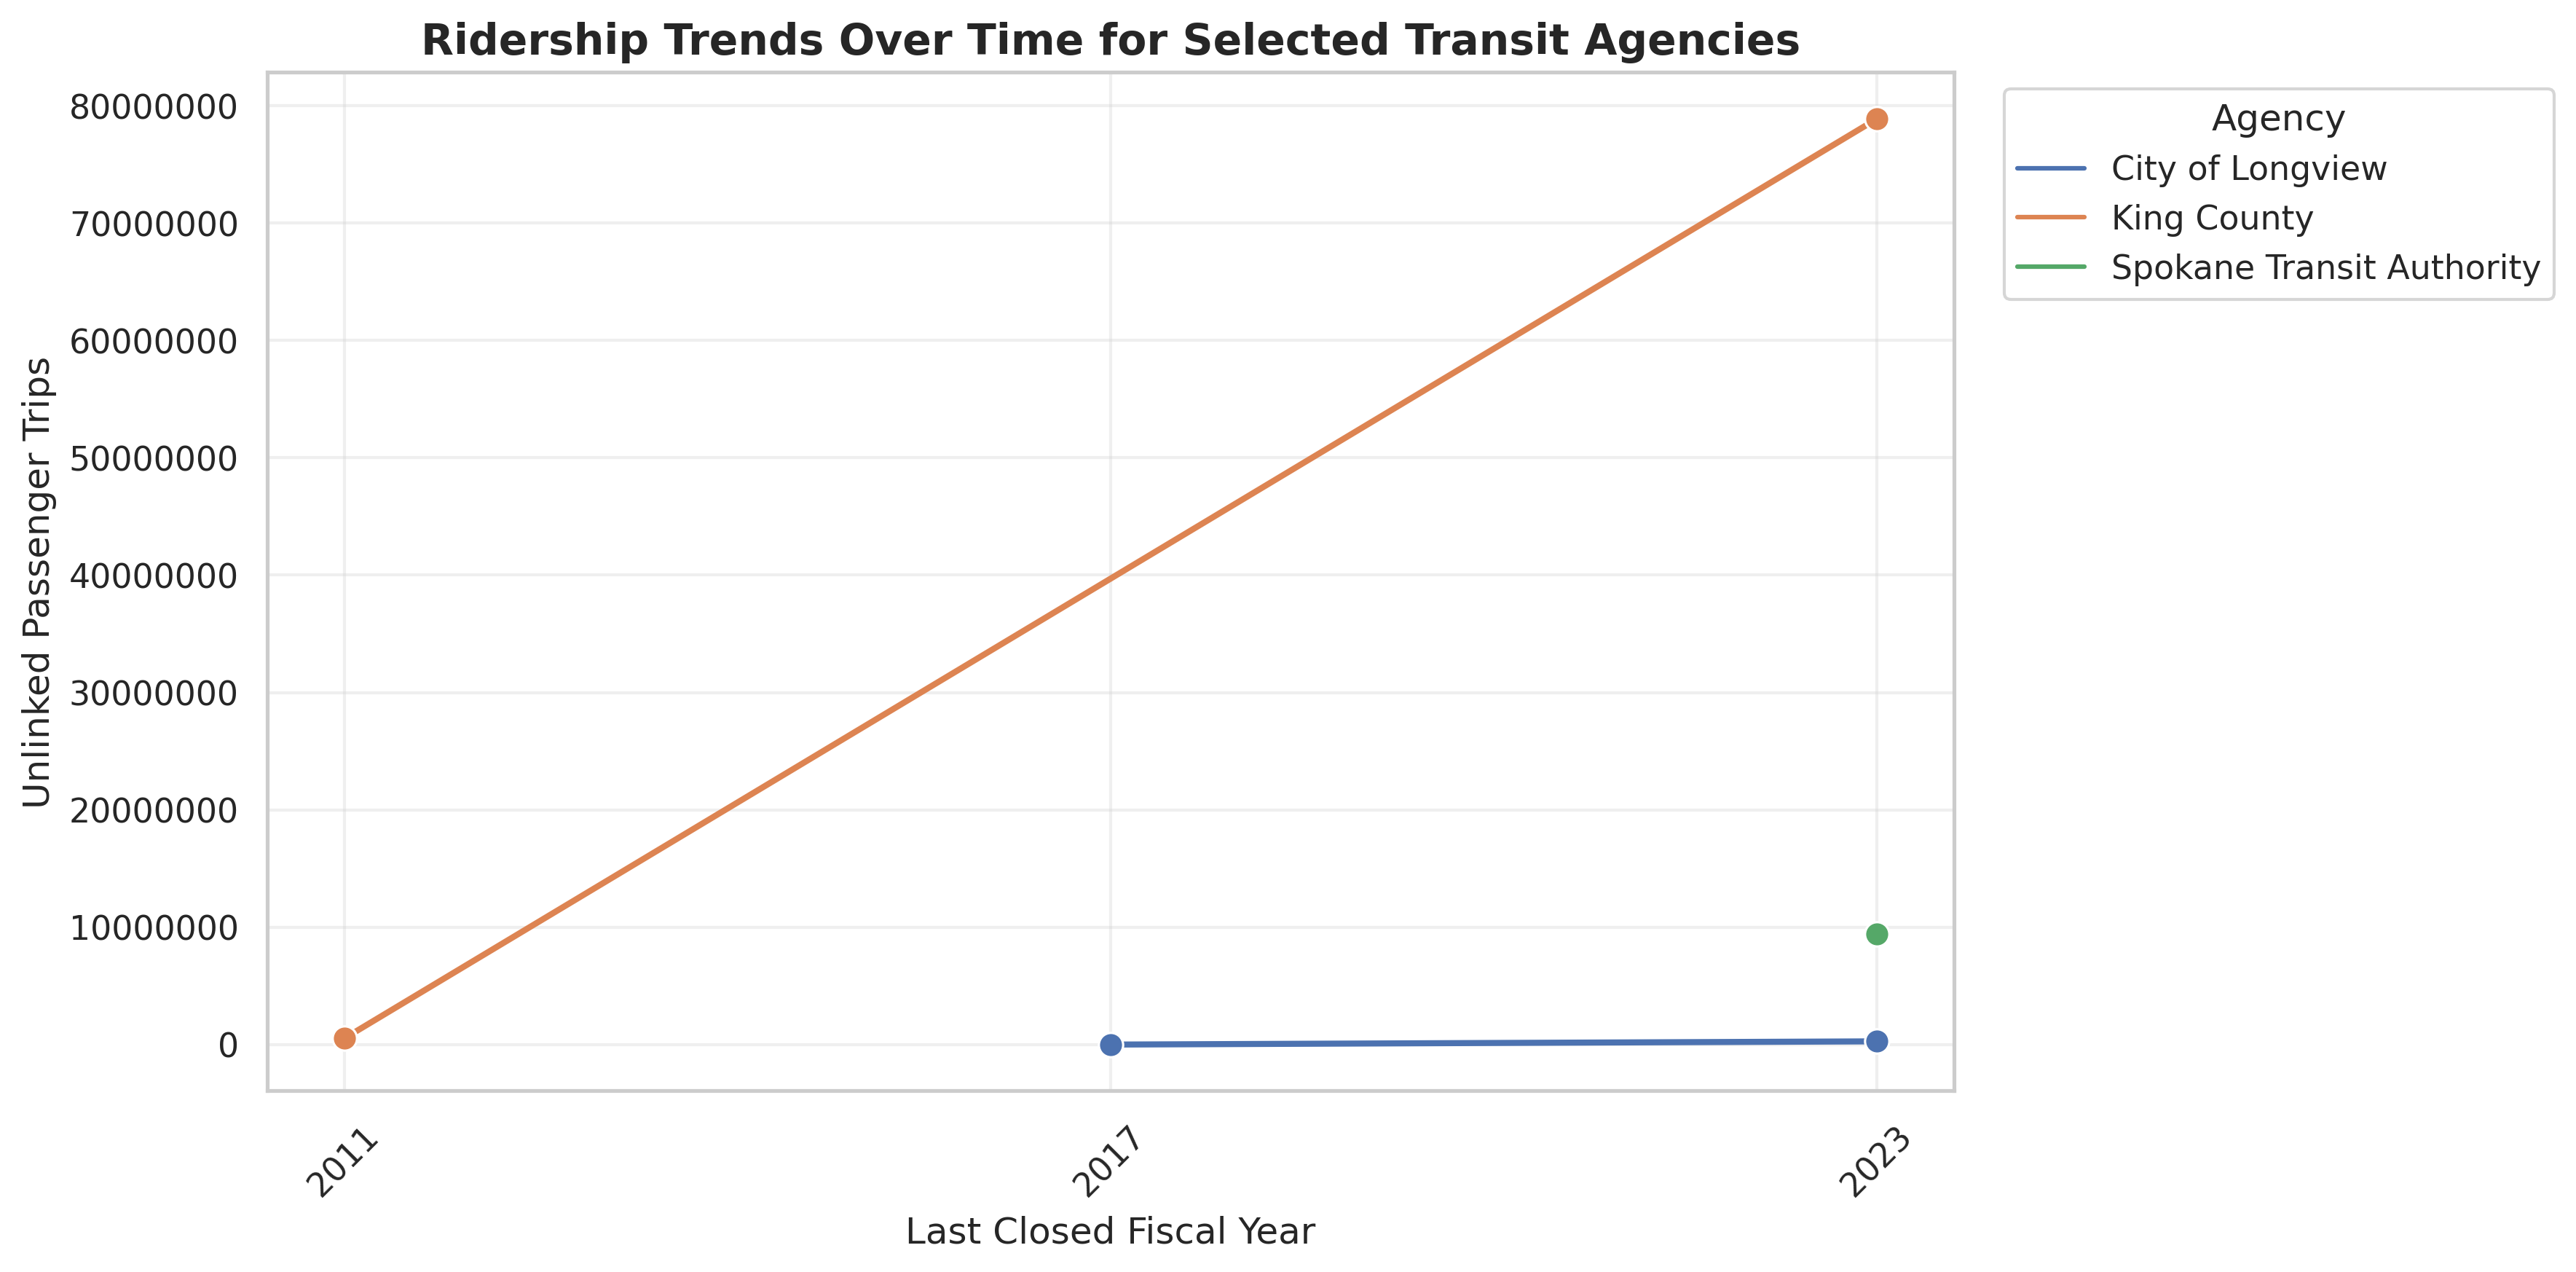

In [9]:
# Load the dataset
data_path = "data/Feb_2025_Complete_Monthly_Ridership.csv"
data = pd.read_csv(data_path)

# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Define the three agencies required by the assignment
neighborhoods = [
    "King County",
    "City of Longview",
    "Spokane Transit Authority"
]

# Filter the dataset to the selected agencies
filtered_data = data[
    data["Agency"].isin(neighborhoods)
].copy()

# Confirm that matching records were found
if filtered_data.empty:
    raise ValueError(
        "No records matched the selected agency names."
    )

# Define the exact columns contained in this dataset
year_column = "Last Closed FY End Year"
agency_column = "Agency"
ridership_column = "Unlinked Passenger Trips FY"

# Convert the year and ridership columns to numeric values
filtered_data[year_column] = pd.to_numeric(
    filtered_data[year_column],
    errors="coerce"
)

filtered_data[ridership_column] = pd.to_numeric(
    filtered_data[ridership_column]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# Remove rows missing values required for the chart
chart_data = filtered_data.dropna(
    subset=[
        year_column,
        agency_column,
        ridership_column
    ]
).copy()

# Convert fiscal years to integers
chart_data[year_column] = chart_data[
    year_column
].astype(int)

# Sum ridership when an agency has multiple mode records
# within the same fiscal year
ridership_trends = (
    chart_data
    .groupby(
        [year_column, agency_column],
        as_index=False
    )[ridership_column]
    .sum()
    .sort_values(
        [agency_column, year_column]
    )
)

# Display the data being used for the visualization
print("Ridership trend data:")
display(ridership_trends)

# Apply a consistent chart theme
sns.set_theme(style="whitegrid")

# Create the line chart
figure, axis = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=ridership_trends,
    x=year_column,
    y=ridership_column,
    hue=agency_column,
    marker="o",
    linewidth=2,
    markersize=8,
    ax=axis
)

# Add the title and axis labels
axis.set_title(
    "Ridership Trends Over Time for Selected Transit Agencies",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Last Closed Fiscal Year")
axis.set_ylabel("Unlinked Passenger Trips")

# Display complete numbers rather than scientific notation
axis.ticklabel_format(
    style="plain",
    axis="y"
)

# Display each available fiscal year on the x-axis
axis.set_xticks(
    sorted(
        ridership_trends[
            year_column
        ].unique()
    )
)
axis.tick_params(
    axis="x",
    rotation=45
)

# Position the legend outside the chart
axis.legend(
    title="Agency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

axis.grid(True, alpha=0.3)
figure.tight_layout()

# Create the output folder
os.makedirs(
    "output",
    exist_ok=True
)

# Save the visualization as a PNG
output_path = "output/ridership_trends.png"

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

# Close the figure to prevent duplicate output
plt.close(figure)

# Display the saved image in the exported HTML
display(
    Image(filename=output_path)
)

### Visualization 2: Bar chart comparing total ridership across neighborhoods
This is an example visualization you can generate. You may implement a chart and assessment of your choosing in lieu of this placeholder.

#### At a minimum include the following actions:
- Add title and axis labels
- Save the plot to a png file in the 'output' folder
- Use the display() function to render the generated png image in the html output
- Comments explaining each step of your analysis

Latest reported ridership by agency:


,Agency,Unlinked Passenger Trips FY
0,City of Longview,274804
2,Spokane Transit Authority,9403739
1,King County,78886848


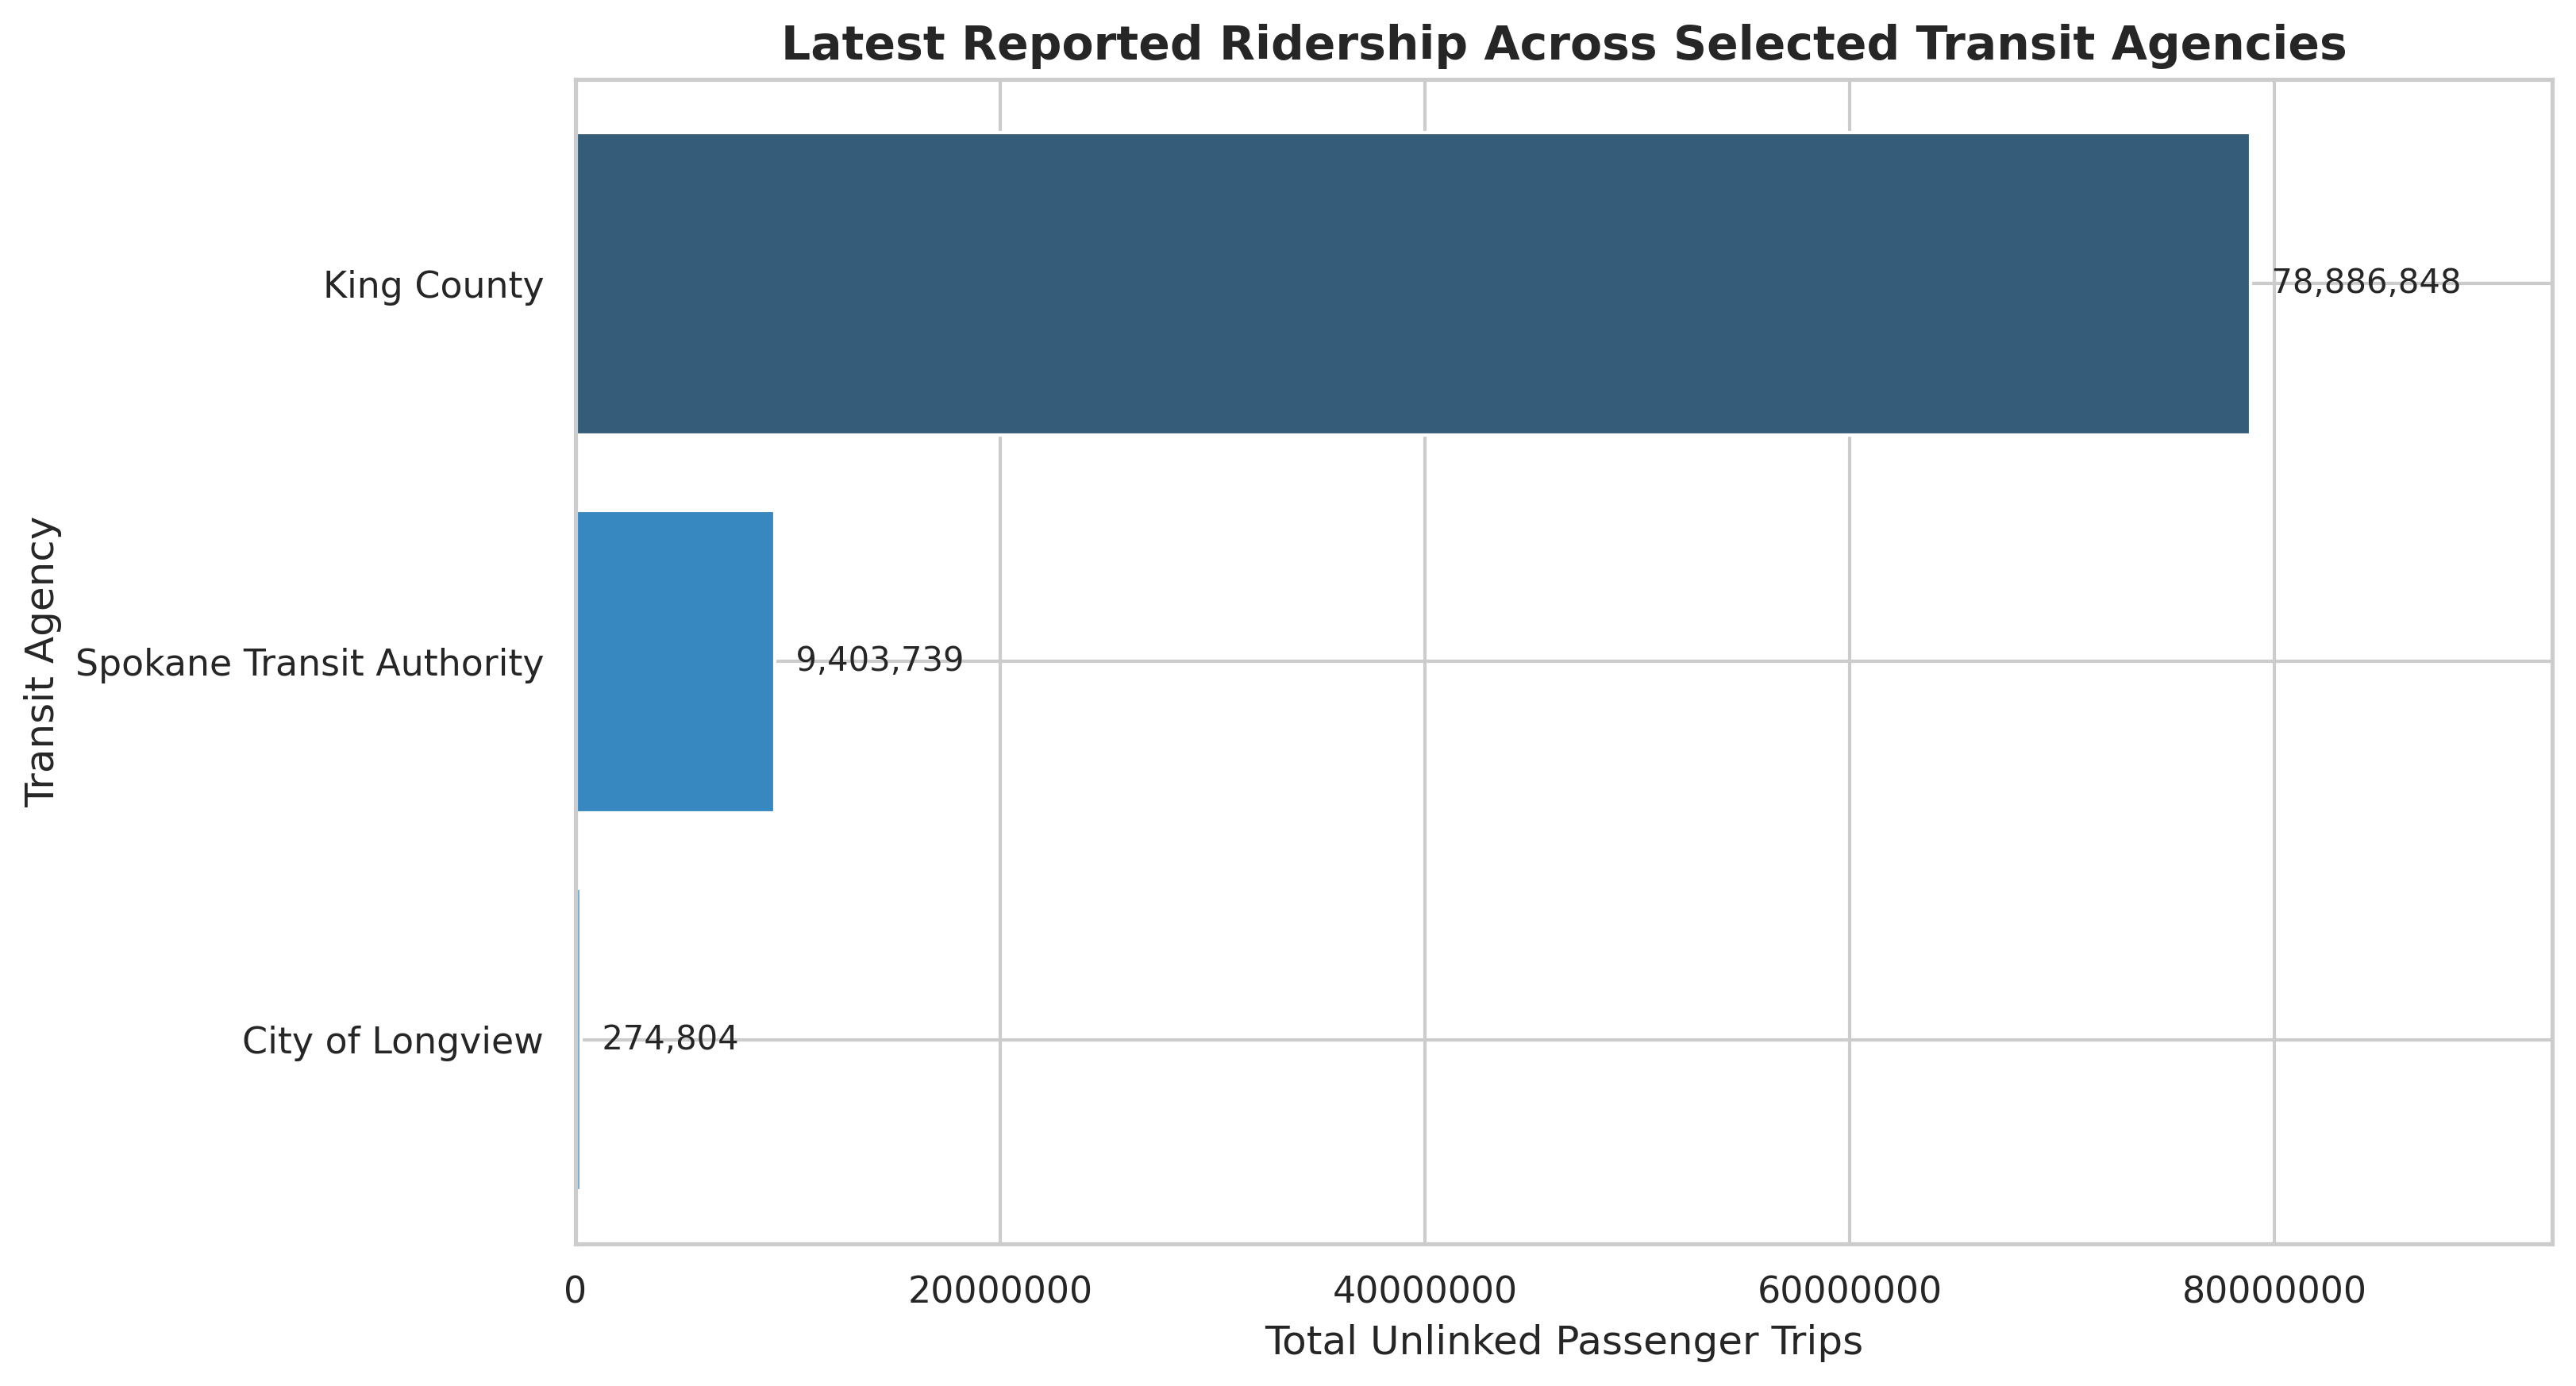

In [10]:
# Load the original dataset
data_path = "data/Feb_2025_Complete_Monthly_Ridership.csv"
data = pd.read_csv(data_path)

# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Define the three agencies used in the analysis
neighborhoods = [
    "King County",
    "City of Longview",
    "Spokane Transit Authority"
]

# Filter the dataset to the selected agencies
bar_data = data[
    data["Agency"].isin(neighborhoods)
].copy()

# Define the columns required for the visualization
year_column = "Last Closed FY End Year"
agency_column = "Agency"
ridership_column = "Unlinked Passenger Trips FY"

# Convert the fiscal year column to numeric values
bar_data[year_column] = pd.to_numeric(
    bar_data[year_column],
    errors="coerce"
)

# Remove commas and convert ridership to numeric values
bar_data[ridership_column] = pd.to_numeric(
    bar_data[ridership_column]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# Remove records missing required values
bar_data = bar_data.dropna(
    subset=[
        year_column,
        agency_column,
        ridership_column
    ]
).copy()

# Stop if no usable records remain
if bar_data.empty:
    raise ValueError(
        "No complete records are available for Visualization 2."
    )

# Identify the latest reported fiscal year for each agency
latest_year_by_agency = (
    bar_data
    .groupby(agency_column)[year_column]
    .transform("max")
)

# Keep only each agency's latest fiscal-year records
latest_bar_data = bar_data[
    bar_data[year_column].eq(latest_year_by_agency)
].copy()

# Sum ridership across transportation modes for each agency
agency_totals = (
    latest_bar_data
    .groupby(agency_column, as_index=False)[ridership_column]
    .sum()
    .sort_values(
        ridership_column,
        ascending=True
    )
)

# Display the summarized data used in the chart
print("Latest reported ridership by agency:")
display(agency_totals)

# Apply a consistent visualization theme
sns.set_theme(style="whitegrid")

# Create the horizontal bar chart
figure, axis = plt.subplots(figsize=(11, 6))

bars = axis.barh(
    agency_totals[agency_column],
    agency_totals[ridership_column],
    color=sns.color_palette(
        "Blues_d",
        n_colors=len(agency_totals)
    )
)

# Add a title and axis labels
axis.set_title(
    "Latest Reported Ridership Across Selected Transit Agencies",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Total Unlinked Passenger Trips")
axis.set_ylabel("Transit Agency")

# Display complete numbers instead of scientific notation
axis.ticklabel_format(
    style="plain",
    axis="x"
)

# Add the exact ridership value beside each bar
for bar in bars:
    ridership_value = bar.get_width()

    axis.text(
        ridership_value,
        bar.get_y() + bar.get_height() / 2,
        f"  {ridership_value:,.0f}",
        va="center",
        fontsize=10
    )

# Add space for the value labels
axis.margins(x=0.18)

# Optimize spacing
figure.tight_layout()

# Create the output folder if it does not exist
os.makedirs(
    "output",
    exist_ok=True
)

# Save the visualization as a PNG
output_path = "output/total_ridership_by_agency.png"

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

# Close the figure to prevent duplicate output
plt.close(figure)

# Display the saved PNG in the exported HTML
display(
    Image(filename=output_path)
)

### Visualization 3: Scatterplot of ridership vs population
This is an example visualization you can generate. You may implement a chart and assessment of your choosing in lieu of this placeholder.

#### At a minimum include the following actions:
- Add title and axis labels
- Save the plot to a png file in the 'output' folder
- Use the display() function to render the generated png image in the html output
- Comments explaining each step of your analysis

Scatterplot data:


,Agency,Unlinked Passenger Trips FY,Service Area Population
0,City of Longview,274804,61598.0
1,King County,78886848,2347800.0
2,Spokane Transit Authority,9403739,471169.0


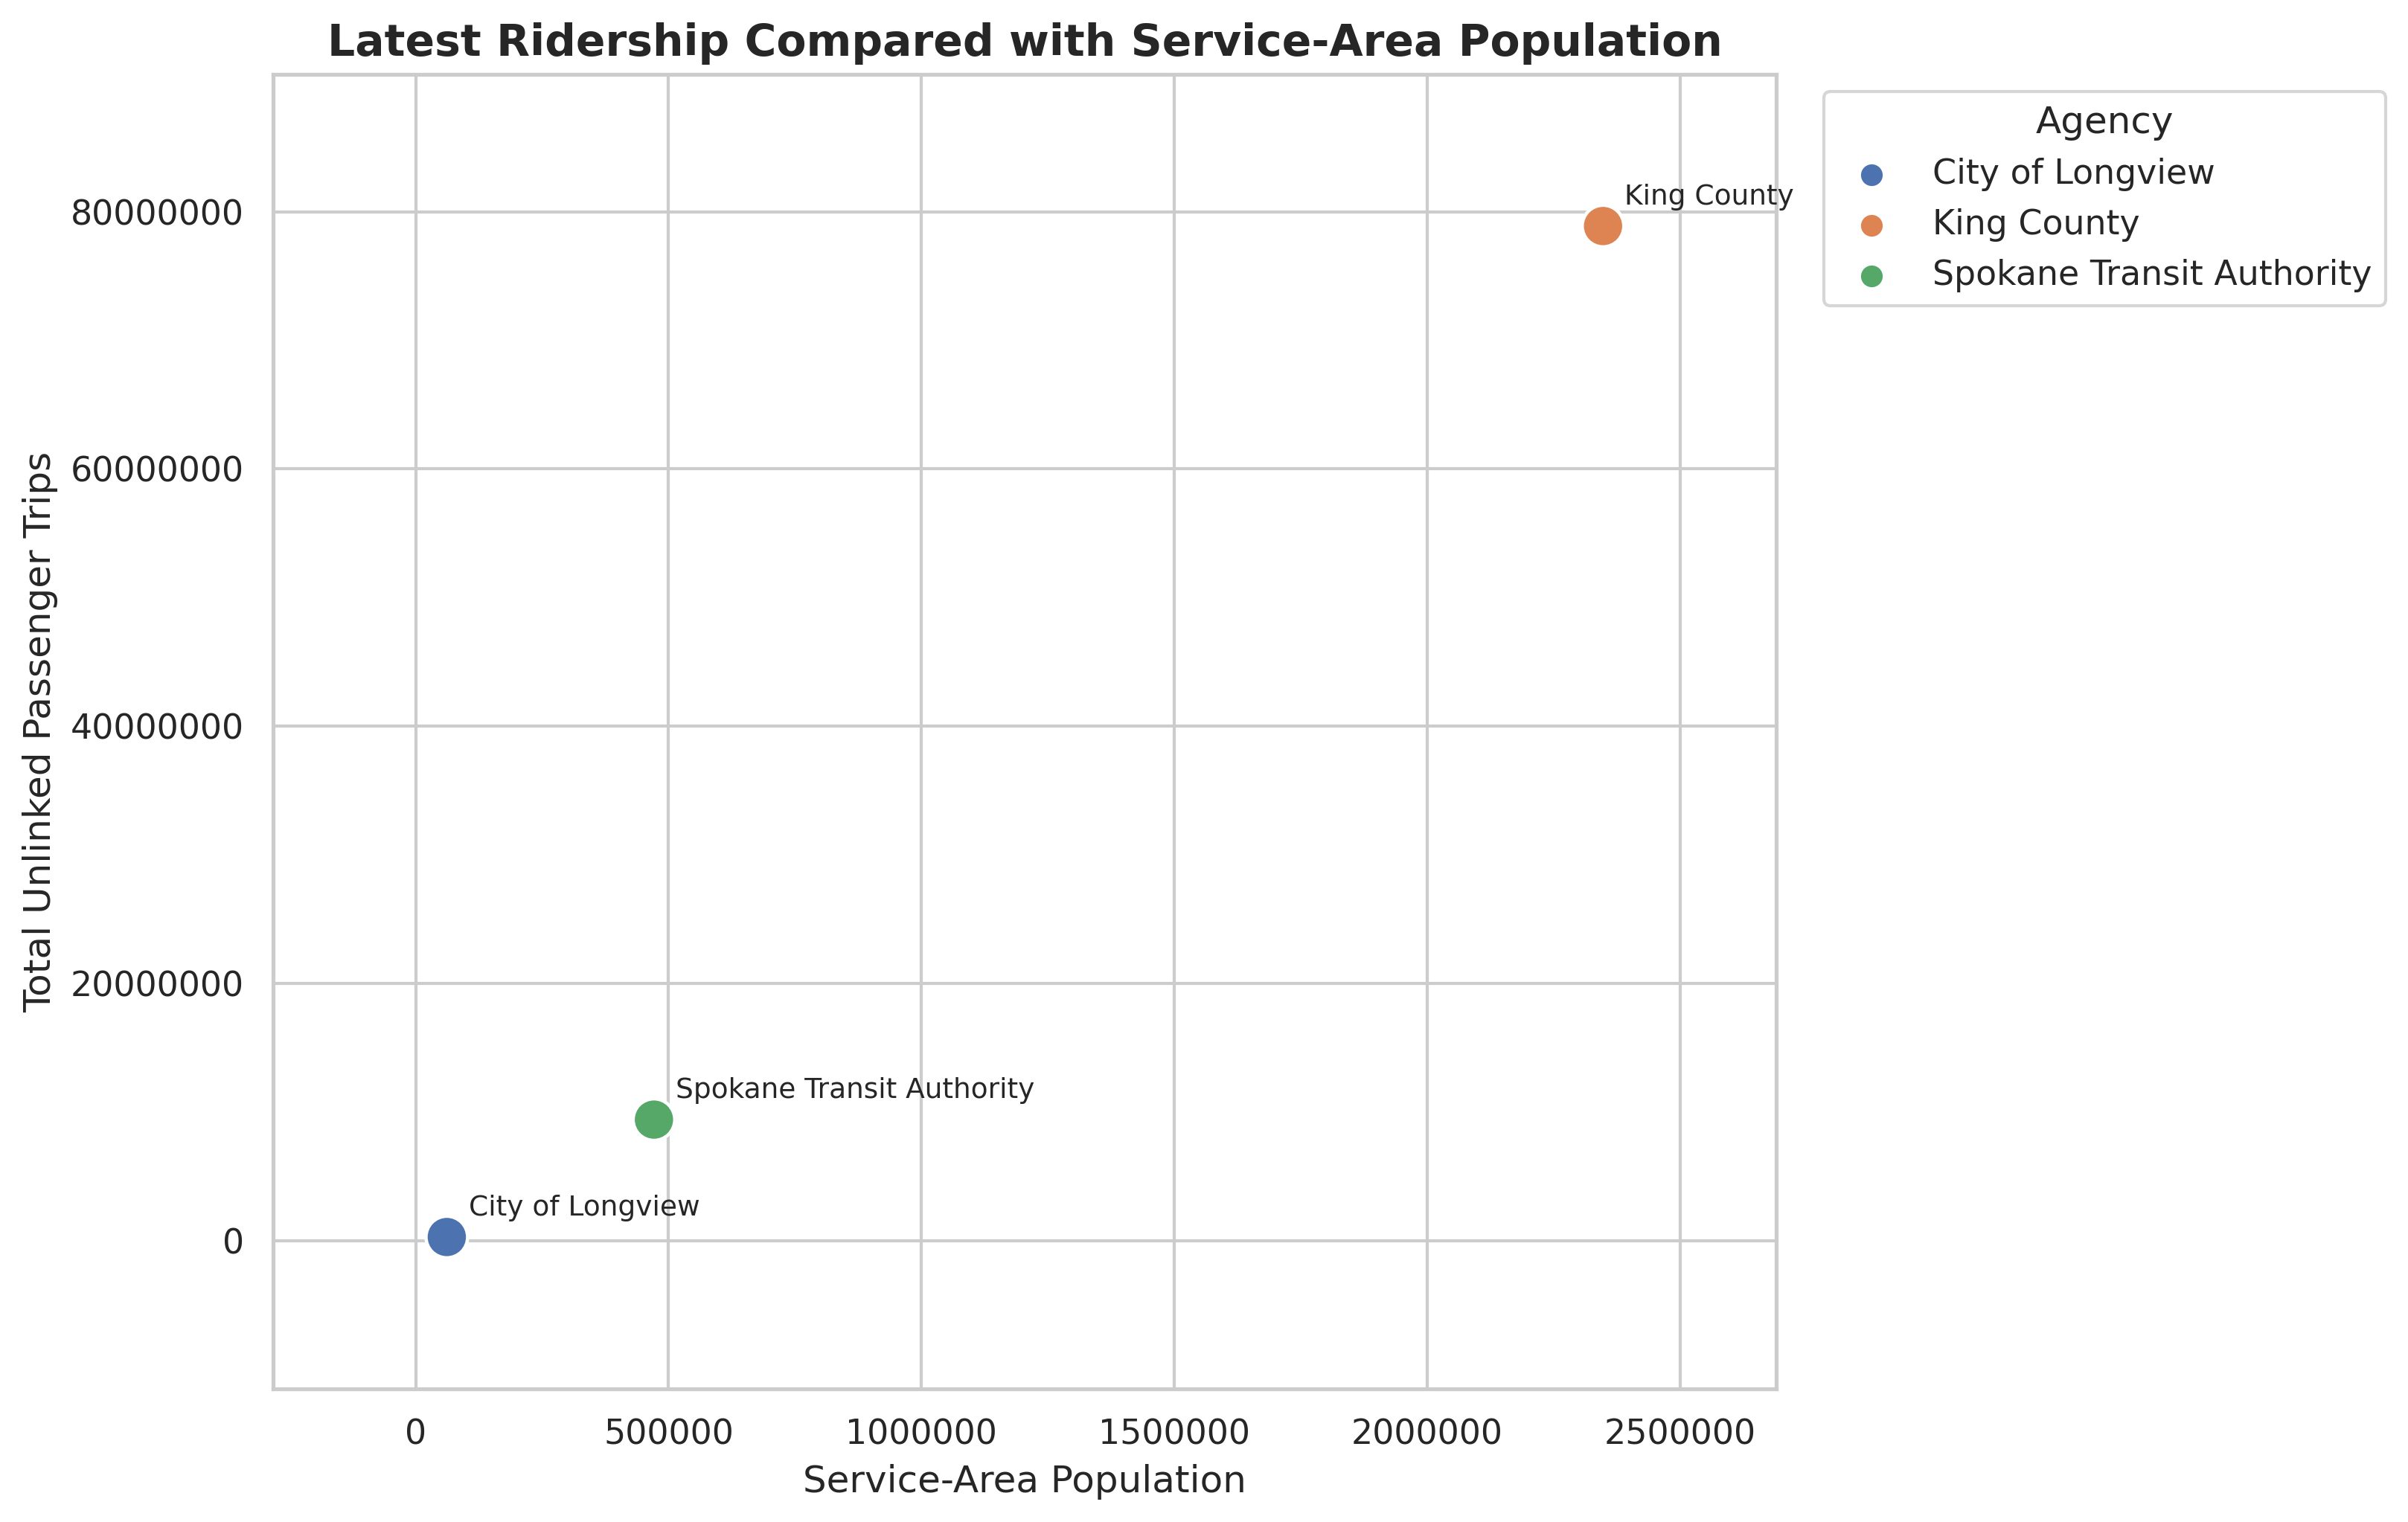

In [11]:
# Load the original dataset
data_path = "data/Feb_2025_Complete_Monthly_Ridership.csv"
data = pd.read_csv(data_path)

# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Define the three agencies included in the analysis
neighborhoods = [
    "King County",
    "City of Longview",
    "Spokane Transit Authority"
]

# Filter the dataset to the selected agencies
scatter_source = data[
    data["Agency"].isin(neighborhoods)
].copy()

# Define the columns required for the visualization
year_column = "Last Closed FY End Year"
ridership_column = "Unlinked Passenger Trips FY"
population_column = "Service Area Population"

# Convert the required columns to numeric values
numeric_columns = [
    year_column,
    ridership_column,
    population_column
]

for column in numeric_columns:
    scatter_source[column] = pd.to_numeric(
        scatter_source[column]
        .astype("string")
        .str.replace(r"[$,]", "", regex=True)
        .str.strip(),
        errors="coerce"
    )

# Remove records missing values required for the chart
scatter_source = scatter_source.dropna(
    subset=[
        "Agency",
        year_column,
        ridership_column,
        population_column
    ]
).copy()

# Stop if no usable records remain
if scatter_source.empty:
    raise ValueError(
        "No complete records are available for Visualization 3."
    )

# Identify each agency's latest available fiscal year
latest_year_by_agency = (
    scatter_source
    .groupby("Agency")[year_column]
    .transform("max")
)

# Keep only each agency's latest fiscal-year records
latest_data = scatter_source[
    scatter_source[year_column].eq(
        latest_year_by_agency
    )
].copy()

# Sum ridership across transportation modes
# Use the maximum population to prevent duplicate population counting
scatter_data = (
    latest_data
    .groupby("Agency", as_index=False)
    .agg({
        ridership_column: "sum",
        population_column: "max"
    })
)

# Display the summarized data used in the scatterplot
print("Scatterplot data:")
display(scatter_data)

# Apply a consistent visualization theme
sns.set_theme(style="whitegrid")

# Create the scatterplot
figure, axis = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=scatter_data,
    x=population_column,
    y=ridership_column,
    hue="Agency",
    s=180,
    ax=axis
)

# Label each agency's point
for _, row in scatter_data.iterrows():
    axis.annotate(
        row["Agency"],
        (
            row[population_column],
            row[ridership_column]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

# Add the chart title and axis labels
axis.set_title(
    "Latest Ridership Compared with Service-Area Population",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Service-Area Population")
axis.set_ylabel("Total Unlinked Passenger Trips")

# Display complete values rather than scientific notation
axis.ticklabel_format(
    style="plain",
    axis="both"
)

# Add spacing around the plotted points and labels
axis.margins(
    x=0.15,
    y=0.15
)

# Position the legend outside the chart
axis.legend(
    title="Agency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Optimize the chart spacing
figure.tight_layout()

# Create the output folder if it does not exist
os.makedirs(
    "output",
    exist_ok=True
)

# Save the visualization as a PNG
output_path = "output/ridership_vs_population.png"

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

# Close the figure to prevent duplicate notebook output
plt.close(figure)

# Display the saved PNG in the exported HTML
display(
    Image(filename=output_path)
)